# Import Libraries

In [45]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import numpy as np
import os
import sys
import copy
import pandas as pd
from matplotlib.ticker import ScalarFormatter


from scipy import signal
from scipy.interpolate import interp1d
import scipy.ndimage.filters


sys.path.append('..')
import libfmp.b
import libfmp.c1
import libfmp.c3




# Performance Analysis using DTW 

This notebook is based on the python notebook in the "Application: Tempo Curve" section of the FMP book as below.  

https://www.audiolabs-erlangen.de/resources/MIR/FMP/C3/C3S3_MusicAppTempoCurve.html

In this notebook, we analyze two renditions of Mozart's Piano Sonata No.16 Cmaj, K545, II. Andante, by Korean pianists, Son Yeol Eum (손열음) and Sunwoo Yekwon (선우예권).

The two audio files were extracted from these YouTube videos.
- 
- https://www.youtube.com/watch?v=pPTImgeod6M (선우예권)

## Computing Chromagram from Score MIDI and Audio Files

First six note events of score CVS file:
   Start  Duration  Pitch  Velocity Instrument
0   0.00      0.25   55.0  0.708660      piano
1   0.00      2.00   71.0  0.496062      piano
2   0.25      0.25   62.0  0.708660      piano
3   0.50      0.25   59.0  0.708660      piano
4   0.75      0.25   62.0  0.708660      piano
5   1.00      0.25   55.0  0.708660      piano


<ipython-input-4-4c512ec24472>:77: FutureWarning: Pass sr=22050 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  x1, Fs = librosa.load(fn_wav, Fs)
<ipython-input-4-4c512ec24472>:93: FutureWarning: Pass sr=22050 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  x2, Fs = librosa.load(fn_wav, Fs)


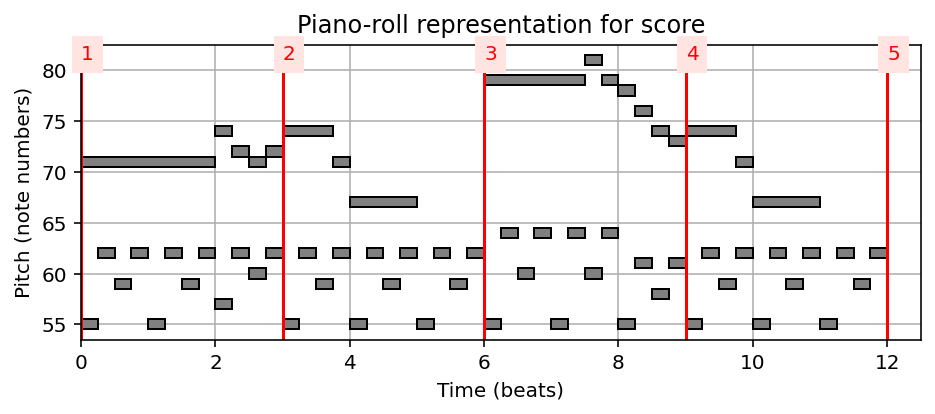

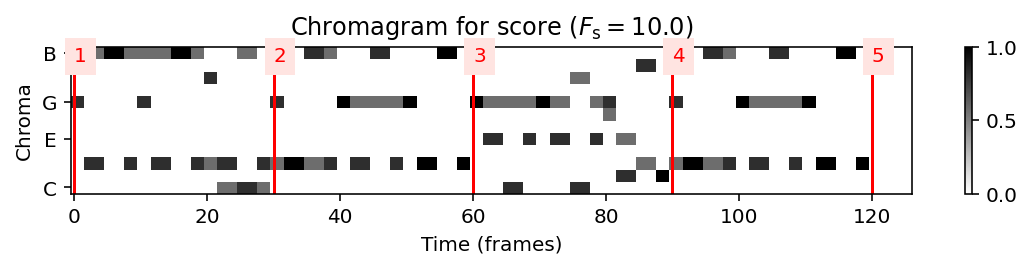

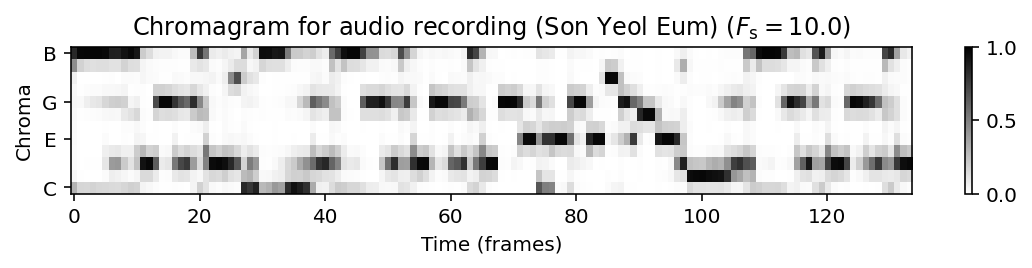

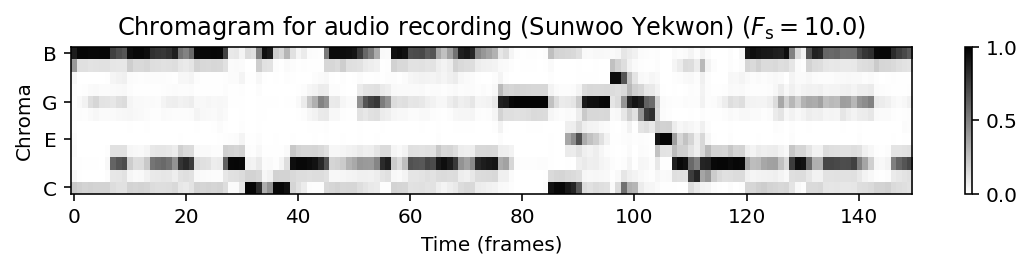

In [4]:
def compute_score_chromagram(score, Fs_beat):
    """Compute chromagram from score representation

    Notebook: C3/C3S3_MusicAppTempoCurve.ipynb

    Args:
        score (list): Score representation
        Fs_beat (scalar): Sampling rate for beat axis

    Returns:
        X_score (np.ndarray): Chromagram representation X_score
        t_beat (np.ndarray): Time axis t_beat (given in beats)
    """
    score_beat_min = min(n[0] for n in score)
    score_beat_max = max(n[0] + n[1] for n in score)
    beat_res = 1.0 / Fs_beat
    t_beat = np.arange(score_beat_min, score_beat_max, beat_res)
    X_score = np.zeros((12, len(t_beat)))

    for start, duration, pitch, velocity, label in score:
        start_idx = int(round(start / beat_res))
        end_idx = int(round((start + duration) / beat_res))
        cur_chroma = int(round(pitch)) % 12
        X_score[cur_chroma, start_idx:end_idx] += velocity

    X_score = librosa.util.normalize(X_score, norm=2)
    return X_score, t_beat

def plot_measure(ax, measure_pos):
    """Plot measure positions

    Notebook: C3/C3S3_MusicAppTempoCurve.ipynb

    Args:
        ax (mpl.axes.Axes): Figure axis
        measure_pos (list or np.ndarray): Array containing measure positions
    """
    y_min, y_max = ax.get_ylim()
    ax.vlines(measure_pos, y_min, y_max, color='r')
    for m in range(len(measure_pos)):
        ax.text(measure_pos[m], y_max, '%s' % (m + 1),
                color='r', backgroundcolor='mistyrose',
                verticalalignment='top', horizontalalignment='left')
    

# Read score file and plot piano-roll representation
fn_score = os.path.join('../audio', 'mozart-4m.csv')
measure_pos_beat = np.array([0, 3, 6, 9, 12])
df = pd.read_csv(fn_score, sep=';')
print('First six note events of score CVS file:')
print(df.loc[0:5, :])

score = libfmp.c1.csv_to_list(fn_score)
fig, ax = libfmp.c1.visualize_piano_roll(score, xlabel='Time (beats)', 
                                         ylabel='Pitch (note numbers)', 
                                         colors=['gray'], 
                                         velocity_alpha=False, figsize=(6.6, 3))
ax.set_title('Piano-roll representation for score')
ax.get_legend().remove()
plot_measure(ax, measure_pos_beat)
plt.tight_layout()

 # Compute and plot score-based chromagram
Fs_beat = 10
X_score, t_beat = compute_score_chromagram(score, Fs_beat)
figsize = (8, 2)
fig, ax, im = libfmp.b.plot_chromagram(X_score, Fs=1, figsize=figsize, 
                                       xlabel='Time (frames)', 
                                       title='Chromagram for score ($F_\mathrm{s} = %.1f$)'%Fs_beat,
                                       chroma_yticks=[0, 4, 7, 11])
plot_measure(ax[0], measure_pos_beat * Fs_beat)
plt.tight_layout()

# Read Piano Music (Son Yeol Eum) 
Fs = 22050
fn_wav = os.path.join('../audio','mozart-4m-son.wav')
x1, Fs = librosa.load(fn_wav, Fs)

# Compute and plot chromagram
N = 4410
H = 2205
Fs_X = Fs / 2205
X1 = librosa.feature.chroma_stft(y=x1, sr=Fs, norm=2, tuning=0, hop_length=H, n_fft=N)
libfmp.b.plot_chromagram(X1, figsize=figsize, xlabel='Time (frames)', clim=[0, 1],
                         title='Chromagram for audio recording (Son Yeol Eum) ($F_\mathrm{s} = %.1f$)'%Fs_X, 
                         chroma_yticks=[0, 4, 7, 11])
plt.tight_layout()


# Read Piano Music (Sunwoo Yekwon) 
Fs = 22050
fn_wav = os.path.join('../audio','mozart-4m-sunwoo.wav')
x2, Fs = librosa.load(fn_wav, Fs)

# Compute and plot chromagram
N = 4410
H = 2205
Fs_X = Fs / 2205
X2 = librosa.feature.chroma_stft(y=x2, sr=Fs, norm=2, tuning=0, hop_length=H, n_fft=N)
libfmp.b.plot_chromagram(X2, figsize=figsize, xlabel='Time (frames)', clim=[0, 1],
                         title='Chromagram for audio recording (Sunwoo Yekwon) ($F_\mathrm{s} = %.1f$)'%Fs_X, 
                         chroma_yticks=[0, 4, 7, 11])
plt.tight_layout()

## Computing DTW between audio and score 

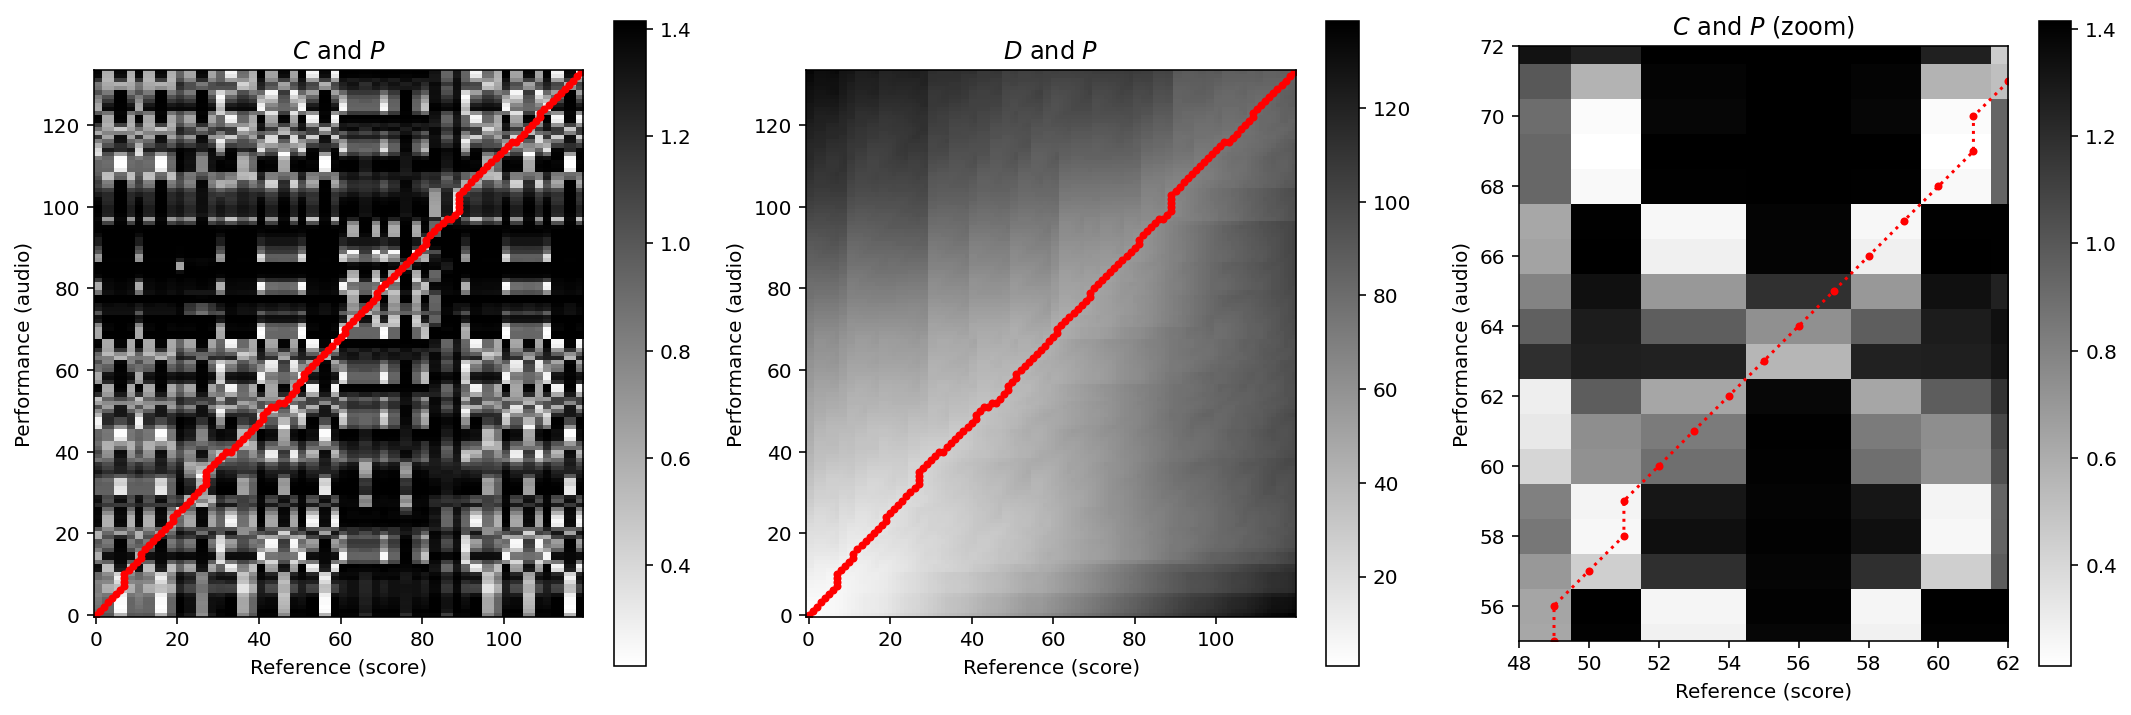

In [31]:
# Compute DTW and plot C, D, P (Son Yeol Eum) 
C1 = libfmp.c3.compute_cost_matrix(X1, X_score, metric='euclidean')
sigma = np.array([[1, 0], [0, 1], [1, 1]])
D1, P1 = librosa.sequence.dtw(C=C1, step_sizes_sigma=sigma)
P1 = P1[::-1, :]  # reverse P

fig, ax = plt.subplots(1, 3, figsize=(15, 5))    
libfmp.c3.plot_matrix_with_points(C1, P1, linestyle=':', marker='.', ax=[ax[0]],  
                                  ylabel='Performance (audio)', xlabel='Reference (score)',
                                  title='$C$ and $P$', aspect='equal')
libfmp.c3.plot_matrix_with_points(D1, P1, linestyle=':', marker='.', ax=[ax[1]],  
                                  ylabel='Performance (audio)', xlabel='Reference (score)',
                                  title='$D$ and $P$', aspect='equal')
libfmp.c3.plot_matrix_with_points(C1, P1, linestyle=':', marker='.', ax=[ax[2]],  
                                  ylabel='Performance (audio)', xlabel='Reference (score)',
                                  title='$C$ and $P$ (zoom)', aspect='equal')
zoom_beat = np.array([4.8, 6.2])
zoom_sec = np.array([5.5, 7.2])
ax[2].set_xlim(zoom_beat * Fs_beat)
ax[2].set_ylim(zoom_sec * Fs_X)
plt.tight_layout()

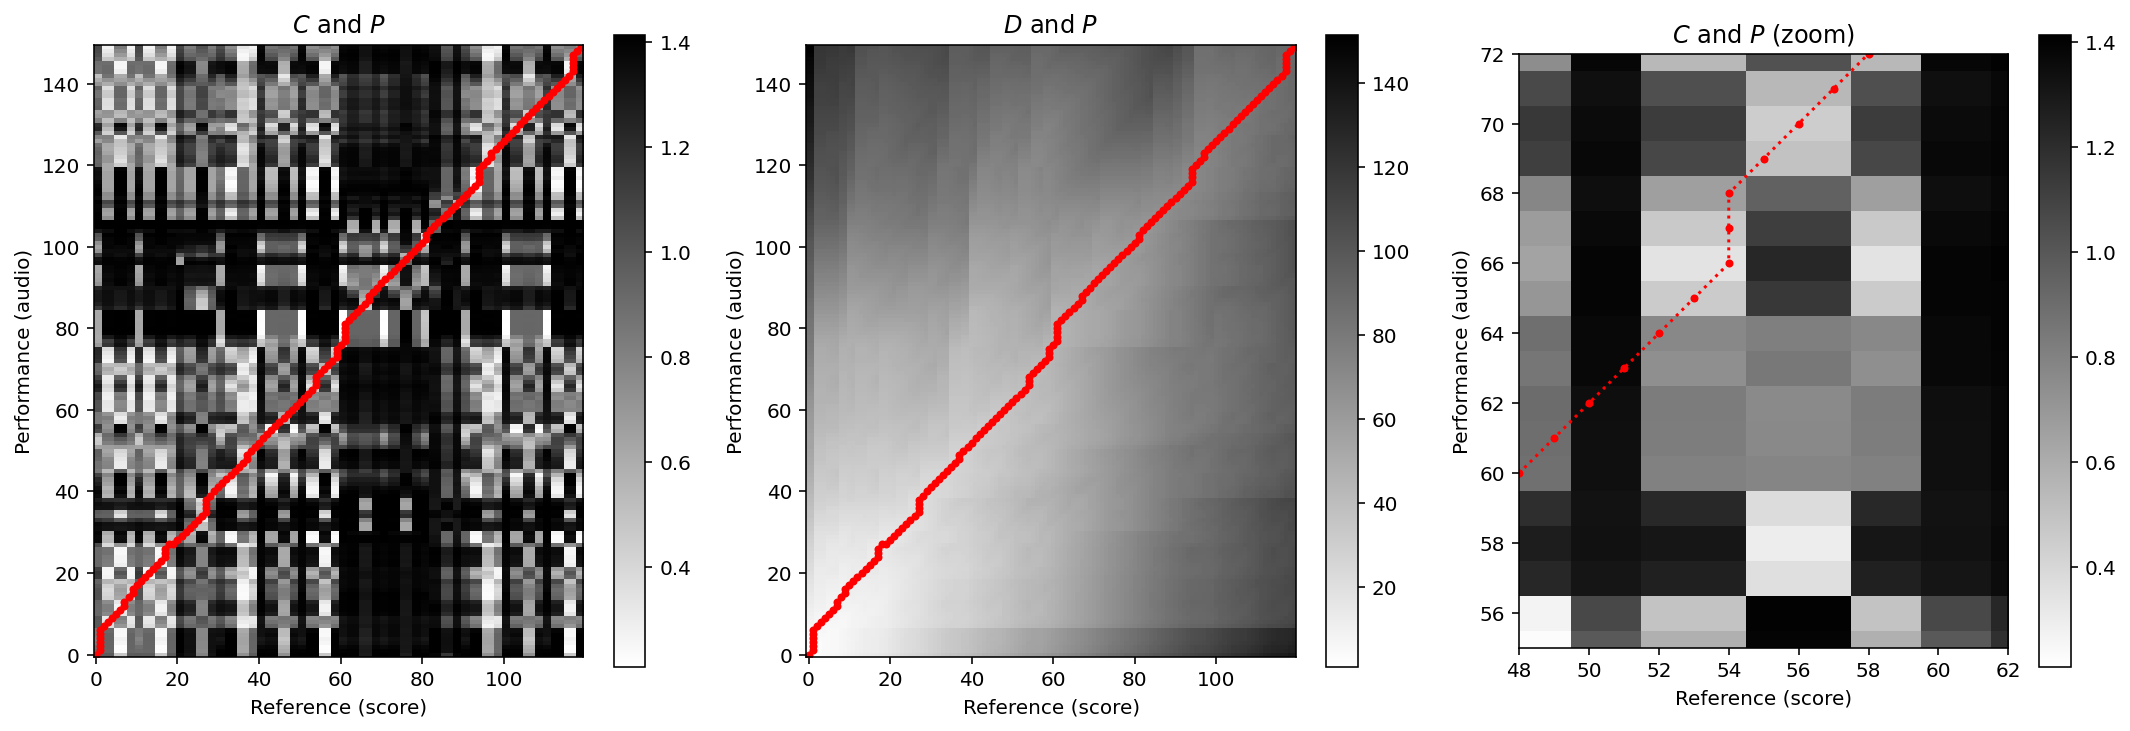

In [32]:
# Compute DTW and plot C, D, P (Sunwoo Yekwon) 
C2 = libfmp.c3.compute_cost_matrix(X2, X_score, metric='euclidean')
sigma = np.array([[1, 0], [0, 1], [1, 1]])
D2, P2 = librosa.sequence.dtw(C=C2, step_sizes_sigma=sigma)
P2 = P2[::-1, :]  # reverse P

fig, ax = plt.subplots(1, 3, figsize=(15, 5))    
libfmp.c3.plot_matrix_with_points(C2, P2, linestyle=':', marker='.', ax=[ax[0]],  
                                  ylabel='Performance (audio)', xlabel='Reference (score)',
                                  title='$C$ and $P$', aspect='equal')
libfmp.c3.plot_matrix_with_points(D2, P2, linestyle=':', marker='.', ax=[ax[1]],  
                                  ylabel='Performance (audio)', xlabel='Reference (score)',
                                  title='$D$ and $P$', aspect='equal')
libfmp.c3.plot_matrix_with_points(C2, P2, linestyle=':', marker='.', ax=[ax[2]],  
                                  ylabel='Performance (audio)', xlabel='Reference (score)',
                                  title='$C$ and $P$ (zoom)', aspect='equal')
zoom_beat = np.array([4.8, 6.2])
zoom_sec = np.array([5.5, 7.2])
ax[2].set_xlim(zoom_beat * Fs_beat)
ax[2].set_ylim(zoom_sec * Fs_X)
plt.tight_layout()

## Calculating "strictly monotonous alignment path" to avoid horizonal and vertial paths

In [33]:
def compute_strict_alignment_path(P):
    """Compute strict alignment path from a warping path

    Notebook: C3/C3S3_MusicAppTempoCurve.ipynb

    Args:
        P (list or np.ndarray): Warping path

    Returns:
        P_mod (list or np.ndarray): Strict alignment path
    """
    # Initialize P_mod and enforce start boundary condition
    P_mod = np.zeros(P.shape)
    P_mod[0] = P[0]
    N, M = P[-1]
    # Go through all cells of P until reaching last row or column
    assert N > 1 and M > 1, 'Length of sequences must be longer than one.'
    i, j = 0, 0
    n1, m1 = P[i]
    while True:
        i += 1
        n2, m2 = P[i]
        if n2 == N or m2 == M:
            # If last row or column is reached, quit loop
            break
        if n2 > n1 and m2 > m1:
            # Strict monotonicity condition is fulfuilled
            j += 1
            P_mod[j] = n2, m2
            n1, m1 = n2, m2
    j += 1
    # Enforce end boundary condition
    P_mod[j] = P[-1]
    P_mod = P_mod[:j+1]
    return P_mod


P_mod1 =  compute_strict_alignment_path(P1)
P_mod2 =  compute_strict_alignment_path(P2)




## Calculating Tempo Curve 

<ipython-input-67-619e11a1c6ba>:64: DeprecationWarning: Please use `convolve` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  f_diff_smooth_sec = scipy.ndimage.filters.convolve(f_diff_sec, filt_win, mode='nearest')


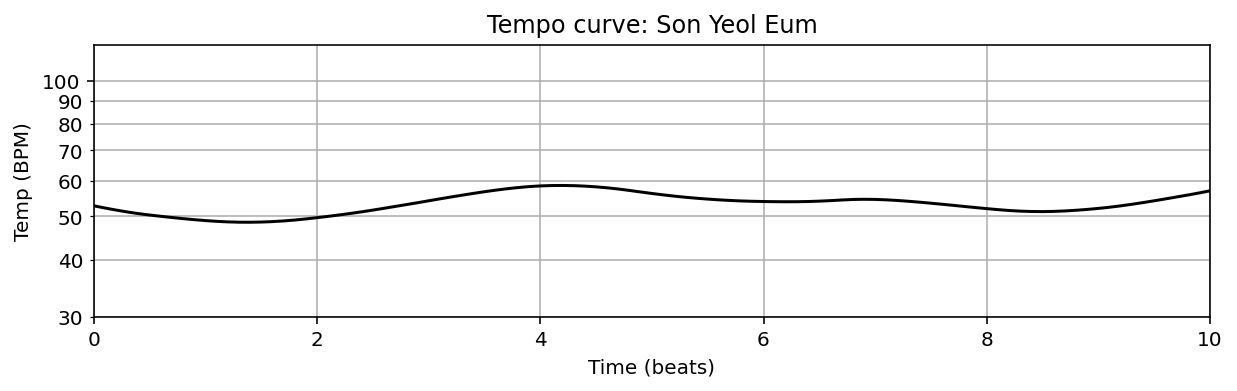

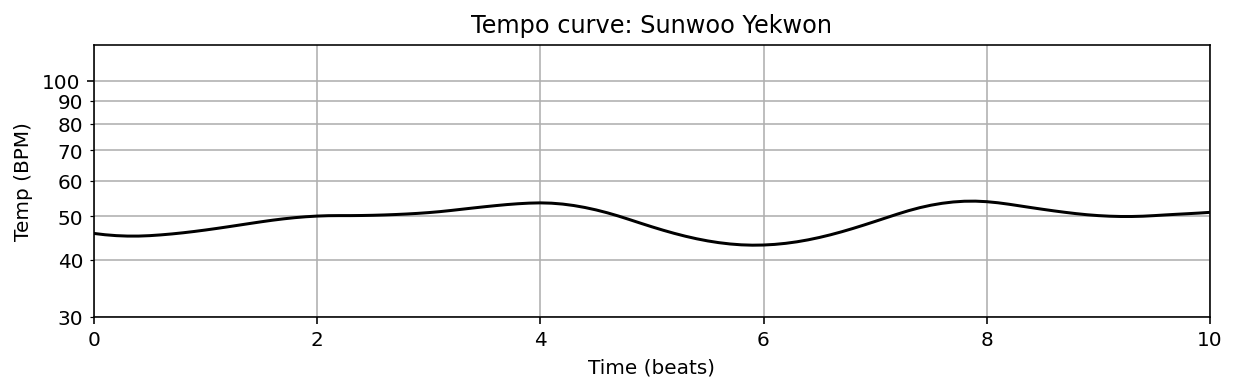

In [67]:
def plot_tempo_curve(f_tempo, t_beat, ax=None, figsize=(10, 2.5), color='k', logscale=False,
                     xlabel='Time (beats)', ylabel='Temp (BPM)', xlim=None, ylim=None,
                     label='', title='', measure_pos=[]):
    """Plot a tempo curve

    Notebook: C3/C3S3_MusicAppTempoCurve.ipynb

    Args:
        f_tempo: Tempo curve
        t_beat: Time axis of tempo curve (given as sampled beat axis)
        ax: Plot either as figure (ax==None) or into axis (ax==True) (Default value = None)
        figsize: Size of figure (Default value = (8, 2))
        color: Color of tempo curve (Default value = 'k')
        logscale: Use linear (logscale==False) or logartihmic (logscale==True) tempo axis (Default value = False)
        xlabel: Label for x-axis (Default value = 'Time (beats)')
        ylabel: Label for y-axis (Default value = 'Temp (BPM)')
        xlim: Limits for x-axis (Default value = None)
        ylim: Limits for x-axis (Default value = None)
        label: Figure labels when plotting into axis (ax==True) (Default value = '')
        measure_pos: Plot measure positions as spefified (Default value = [])

    Returns:
        fig: figure handle
        ax: axes handle
    """
    fig = None
    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = plt.subplot(1, 1, 1)
    ax.plot(t_beat, f_tempo, color=color, label=label)    
    ax.set_title('Tempo curve: ' + title)
    if xlim is None:
        xlim = [t_beat[0], t_beat[-1]]
    if ylim is None:
        ylim = [np.min(f_tempo) * 0.9, np.max(f_tempo) * 1.1]
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, which='both')
    if logscale:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_minor_formatter(ScalarFormatter())
        # ax.set_yticks([], minor=True)
        # yticks = np.arange(ylim[0], ylim[1]+1, 10)
        # ax.set_yticks(yticks)
    plot_measure(ax, measure_pos)
    return fig, ax


def convert_path_tempo_curve(P_mod, win_len_beat=4): 
    # Convert path into beat-time function and interpolte 
    t_path_beat = P_mod[:, 1] / Fs_beat
    f_path_sec = P_mod[:, 0] / Fs_X
    f_sec = interp1d(t_path_beat, f_path_sec, kind='linear', fill_value='extrapolate')(t_beat)

    # Compute difference and smooth with Hann window
    f_diff_sec = np.diff(f_sec) * Fs_beat
    f_diff_sec = np.concatenate((f_diff_sec, np.array([0])))
    filt_len = int(win_len_beat * Fs_beat * 1.1)
    filt_win = signal.hann(filt_len)
    filt_win = filt_win / np.sum(filt_win)
    f_diff_smooth_sec = scipy.ndimage.filters.convolve(f_diff_sec, filt_win, mode='nearest')        
    f_tempo = 1. / f_diff_smooth_sec * 60
    return f_tempo
    
    
f_tempo1 = convert_path_tempo_curve(P_mod1, win_len_beat=4)
plot_tempo_curve(f_tempo1, t_beat, xlim=[0, 10], ylim=[30, 120], logscale=True, title='Son Yeol Eum');


f_tempo2 = convert_path_tempo_curve(P_mod2, win_len_beat=4)
plot_tempo_curve(f_tempo2, t_beat, xlim=[0, 10], ylim=[30, 120], logscale=True, title='Sunwoo Yekwon');
